In [12]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal

In [13]:
class QuadClass(TypedDict):
    a: float 
    b: float 
    c: float
    
    eqn : str
    d : int
    res : str

In [14]:
def show_eqn(state : QuadClass):

    a = state['a']
    b = state['b']
    c = state['c']
    
    eqn = f'{a}x^2 + {b}x + {c}'

    return {'eqn' : eqn}

def cal_d(state : QuadClass) :
    a = state['a']
    b = state['b']
    c = state['c']

    d = (b*b) - (4*a*c)

    return {'d' : d}

def real_roots(state : QuadClass):

    a = state['a']
    b = state['b']
    c = state['c']

    d = state['d']

    root1 = (-b + (d ** 0.5))/(2*a)
    root2 = (-b - (d ** 0.5))/(2*a)

    res = f'The roots are {root1} and {root2}'

    return {'res' : res}

def same_roots(state : QuadClass):

    a = state['a']
    b = state['b']
    c = state['c']

    d = state['d']

    root1 = (-b + (d ** 0.5))/(2*a)

    res = f'The root is {root1}'

    return {'res' : res}

def no_roots(state : QuadClass):

    res = f'No Real Roots are there'

    return {'res' : res}


def condition(state:QuadClass) -> Literal['real_roots' , 'same_roots' , 'no_roots'] :

    if state['d'] ==  0 :
        return 'same_roots'
    
    elif state['d'] > 0 :
        return 'real_roots'
    
    else :
        return 'no_roots'

In [15]:
def cal_res(state: QuadClass):

    d = state['d']

    if d > 0 :
        return {'r', 'Real and Distinct roots'}

    elif d == 0 :
        return {'r' , 'Real and Same roots'}

    else:
        return {'r' , 'Complex Roots'}

# Conditional Statement

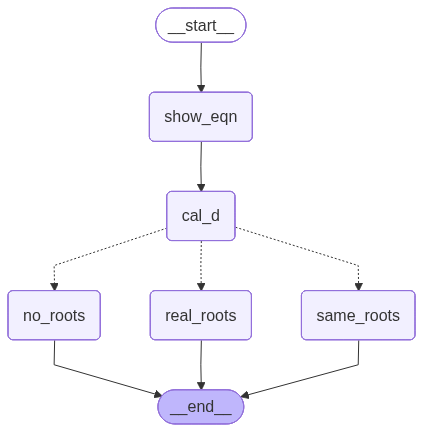

In [16]:
graph = StateGraph(QuadClass)

graph.add_node('show_eqn' , show_eqn)
graph.add_node('cal_d' , cal_d) 
graph.add_node('same_roots' , same_roots)
graph.add_node('no_roots' , no_roots)
graph.add_node('real_roots' , real_roots)

# add edges

graph.add_edge(START , 'show_eqn')
graph.add_edge('show_eqn' , 'cal_d')
graph.add_conditional_edges('cal_d' , condition) # Conditional Statement
graph.add_edge('no_roots' , END)
graph.add_edge('same_roots' , END)
graph.add_edge('real_roots' , END)

# Compile
wf = graph.compile()
wf

In [18]:
ia = int(input("Tell a"))
ib = int(input("Tell b"))
ic = int(input("Tell c"))

inp = {'a' : ia , 'b' : ib , 'c' : ic}

out = wf.invoke(inp)

out

{'a': 1,
 'b': 2,
 'c': 1,
 'eqn': '1x^2 + 2x + 1',
 'd': 0,
 'res': 'The root is -1.0'}